In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# *Linear Regression*

## *Normal Equation*

In [118]:
np.random.seed(42)
X = 2 * np.random.rand(100,1)  # np.random.rand(size)  generates uniformly distributed numbers in [0,1)
y = 3 + 5 * X + np.random.rand(100,1) # np.random.rand(size)  uses noraml distribution

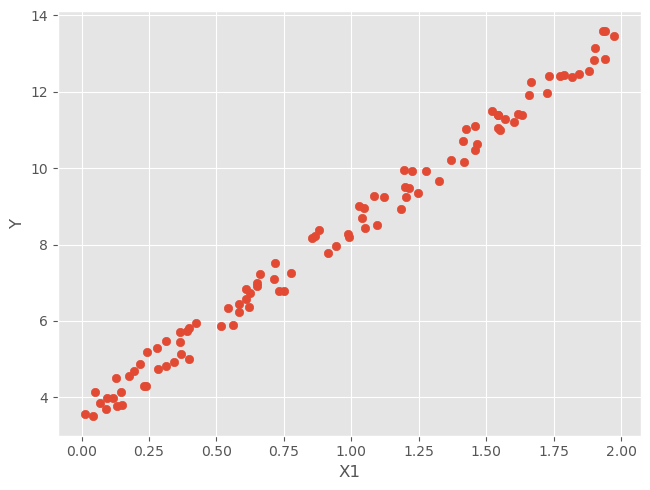

In [119]:
plt.scatter(X,y)
plt.tight_layout()
plt.xlabel("X1")
plt.ylabel("Y")
plt.style.use("ggplot")
plt.show()

In [120]:
# Calculating the Best Theta value(slope & bias)
X_bias = np.c_[np.ones((100,1)),X]  #This adds the extra ones col for bias term
theta_best = np.linalg.inv(X_bias.T.dot(X_bias)).dot(X_bias.T).dot(y)
theta_best

array([[3.51359766],
       [4.98323418]])

**Here we got b as 3.51 & w1 as 4.98 instead of b=3 & w1=5 which is almost close**

In [121]:
# Making predcition using theta 
X_new = np.array([[0],[2]])
X_new_bias = np.c_[np.ones((2,1)),X_new]
y_pred = X_new_bias.dot(theta_best)
print(f"The prediction for new X is: {y_pred}")

The prediction for new X is: [[ 3.51359766]
 [13.48006601]]


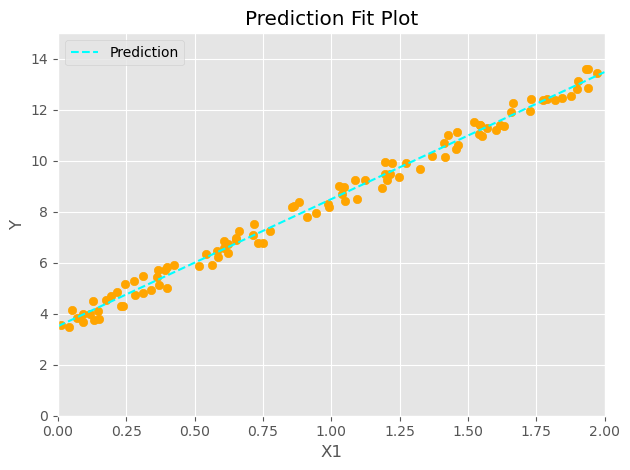

In [122]:
plt.plot(X_new,y_pred,color="cyan",linestyle="--", label="Prediction")
plt.scatter(X,y,c="orange")
plt.axis([0,2,0,15])
plt.xlabel("X1")
plt.ylabel("Y")
plt.title("Prediction Fit Plot")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [123]:
# Lin Reg using Scikit Learn
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(f"The slope and intercept(bias) term of the model are -> {lin_reg.intercept_,lin_reg.coef_}")
print(f"Prediction of the lin model is -> {lin_reg.predict(X_new)}")

The slope and intercept(bias) term of the model are -> (array([3.51359766]), array([[4.98323418]]))
Prediction of the lin model is -> [[ 3.51359766]
 [13.48006601]]


In [124]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_bias,y,rcond=1e-6)
print(f"{theta_best_svd,residuals,rank,s}")

(array([[3.51359766],
       [4.98323418]]), array([8.49565526]), 2, array([14.37020392,  4.11961067]))


# *Gradient Descent*

In [125]:
eta = 0.1 #Learning rate
n_iter = 1000
m = 100

theta = np.random.randn(2,1) # returns a 2X1 mat of std normal function values

for iteration in range(n_iter):
    g = (2/m)*X_bias.T.dot(X_bias.dot(theta)-y)  # Gradient vector
    theta = theta - eta * g
print(f"Final gradient vector is: {theta}")

Final gradient vector is: [[3.51359766]
 [4.98323418]]


**This is same as what we found using normal equation**

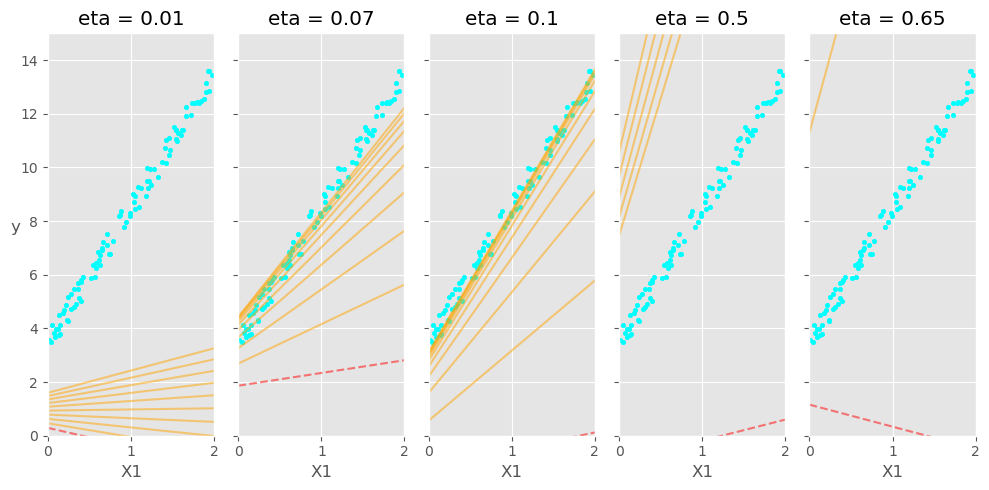

In [126]:
#Ploting GD for different eta values
etas = [0.1,0.5,0.65,0.07,0.01]
etas.sort()
fig,axes = plt.subplots(1,len(etas),figsize=(10,5),sharey=True)

for i,eta in enumerate(etas):
    theta = np.random.randn(2,1)
    ax = axes[i]

    ax.scatter(X,y,color="cyan",s=10)

    for iteration in range(n_iter):
        if(iteration<10):
            y_pred = X_new_bias.dot(theta)
            if iteration == 0:
                ax.plot(X_new,y_pred,"r--",alpha=0.5)
            else:
                ax.plot(X_new,y_pred,color="orange",alpha=0.5)                

        g = (2/m)*X_bias.T.dot(X_bias.dot(theta)-y)
        theta = theta - eta * g

        ax.set_title(f"eta = {eta}")
        ax.set_xlabel("X1")
        if i==0 : ax.set_ylabel("y",rotation=0)
        ax.axis([0,2,0,15])
        
plt.tight_layout()
plt.show()

# *Stochastic Gradient Descent*

In [127]:
n_epochs = 50
t0 = 5
t1 = 50
def learning_schedule(t):
    return t0/(t+t1)

theta = np.random.randn(2,1)
m = 100
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_bias[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradient = 2*xi.T.dot(xi.dot(theta)-yi)
        eta = learning_schedule(epoch*m + i)  # (epoch*m + i) is the total no of iter count
        theta = theta - eta * gradient
print(f"Theta of Stochastic GD is: {theta}")

Theta of Stochastic GD is: [[3.52165654]
 [4.98800241]]


In [128]:
# SGDRegressor Scikit leran
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000,tol=1e-3,penalty=None,eta0=0.1)
sgd_reg.fit(X,y.ravel())
print(f"The slope & intercept of the model using SGD are {sgd_reg.coef_[0]:.4f},{sgd_reg.intercept_[0]:.4f}")

The slope & intercept of the model using SGD are 4.9866,3.5370


# *Polynomial Regression*

In [129]:
m = 100
np.random.seed(42)
X = 6 * np.random.rand(m,1) - 3
y = np.random.randn(m,1) + 2 + X + 0.5 * X**2 

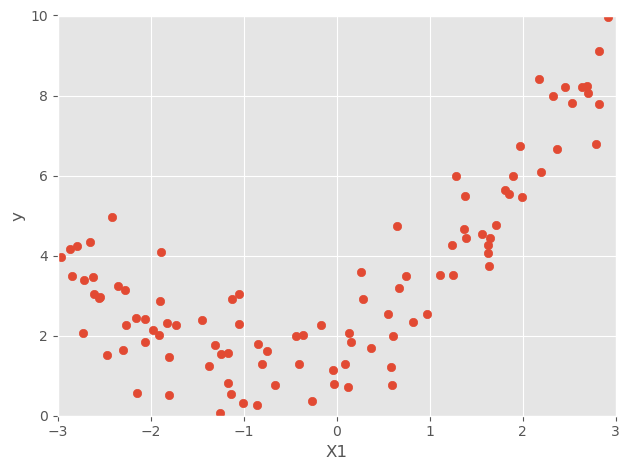

In [130]:
#Plotting the data
plt.scatter(X,y)
plt.xlabel("X1")
plt.ylabel("y")
plt.axis([-3,3,0,10])
plt.tight_layout()
plt.show()

In [131]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
print(f"X[0] is {X[0]}")
print(f"X_ploy[0] is {X_poly[0]}") # This contains X[0] & X[0]^2

X[0] is [-0.75275929]
X_ploy[0] is [-0.75275929  0.56664654]


In [132]:
#Fiting lin reg model
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
print(f"The slope & intercept of the model are {lin_reg.coef_},{lin_reg.intercept_}")

The slope & intercept of the model are [[0.93366893 0.56456263]],[1.78134581]


***Thus h(x) = 0.56$X^2$ + 0.933$X$ + 1.781 while  the real function y = 0.5$X^2$ + $X$ + 2 + Gaussian Noise***

# *Ploting Learning Curves*

In [133]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_lc(model,X,y):
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    train_error ,test_error = [] ,[]
    for m in range(1,len(X_train)):
        model.fit(X_train[:m],y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_test_pred = model.predict(X_test)
        train_error.append(mean_squared_error(y_train[:m],y_train_pred))
        test_error.append(mean_squared_error(y_test,y_test_pred))

    plt.plot(np.sqrt(train_error),color="orange",linestyle="-.",linewidth=2,label="train")
    plt.plot(np.sqrt(test_error),color="cyan",linestyle="-",linewidth=2,label="test")
    plt.title("RMSE_train_test Plot")
    plt.xlabel("Training set size")
    plt.legend(loc="best")
    plt.ylabel("RMSE")
    

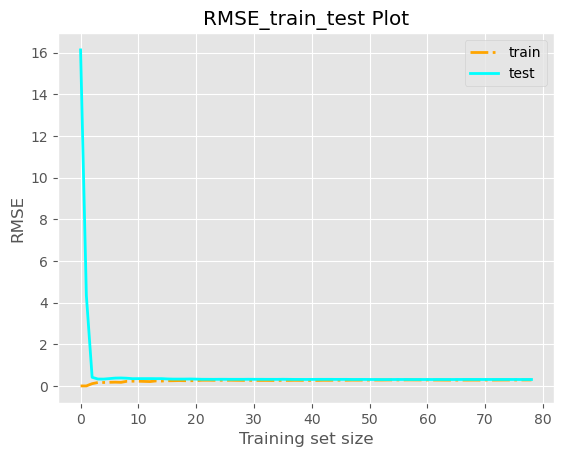

In [134]:
np.random.seed(42)
X_lin = 2 * np.random.rand(100,1)  
y_lin = 3 + 5 * X + np.random.rand(100,1)
plot_lc(lin_reg,X_lin,y_lin)  #For linear data

(0.0, 80.0, 0.0, 3.0)

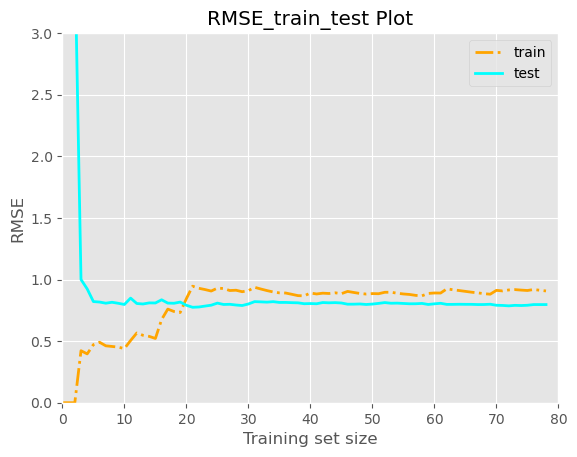

In [135]:
plot_lc(lin_reg,X_poly,y) #For polynomial data of degree 2
plt.axis([0,80,0,3])

(0.0, 80.0, 0.0, 5.0)

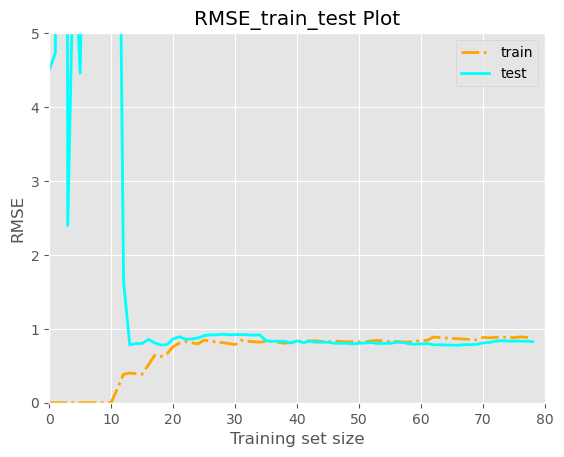

In [136]:
from sklearn.pipeline import Pipeline
poly_pipeline = Pipeline([
    ("ploy_features",PolynomialFeatures(degree=10,include_bias=False)),
    ("lin_reg",LinearRegression()),
])
plot_lc(poly_pipeline,X,y)
plt.axis([0,80,0,5])

***We can clearly see frm the above two plots that in a degree=10 ploy we get less train rmse than dergree=2 that is more gap btw the train & test curve, also the train and test curve overlaps after a certain train set size overfitting the data.***

# *Regularised Linear Models*

## *Ridge Regression*

In [137]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m,1)
y = 1 + 0.5 * X + np.random.randn(m,1) /1.5
X_new = np.linspace(0,3,100).reshape(100,1)

In [138]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1,solver="cholesky") # This uses a matrix factorixation technique by Andre louis Cholesky
ridge_reg.fit(X,y)
ridge_reg.predict([[6.7]])

array([[3.43729382]])

In [139]:
# Ridge Reg Using SGD (with penalty = l2)
sgd_ridge = SGDRegressor(penalty="l2") #This adds a penalty term of l2 norm of weight vector which simply is the ridge regression
sgd_ridge.fit(X,y.ravel())
sgd_ridge.predict([[6.7]])

array([4.68623994])

## *Lasso Regression*

In [140]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.01)
lasso_reg.fit(X,y)
lasso_reg.predict([[6.7]])

array([3.49086414])

In [141]:
# Lasso reg using SGD (with penlaty =l1)
sgd_lasso = SGDRegressor(penalty="l1")
sgd_lasso.fit(X,y.ravel())
sgd_lasso.predict([[6.7]])

array([4.68255739])

## *Elastic Net*

In [160]:
# Elastic Net reg built form scratch
class CustomElasticNet:
    def __init__(self,alpha=0.1,eta=0.01,l1_ratio=0.5,epochs=1000):
        self.alpha = alpha
        self.eta = eta
        self.l1_ratio = l1_ratio
        self.epochs = epochs
        self.theta = None
        self.b = None
    
    def fit(self,X,y):
        m,n = X.shape
        self.theta = np.zeros(n) # here weight is a row vector
        self.b = 0

        for _ in range(self.epochs):
            y_pred = np.dot(X,self.theta) + self.b

            dtheta = (1/m) * np.dot(X.T,(y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            l1_penalty = self.l1_ratio * self.alpha * np.sign(self.theta)
            l2_penalty = (1 - self.l1_ratio) * self.alpha * self.theta

            dtheta += l1_penalty + l2_penalty

            self.theta -= self.eta*dtheta
            self.b -= self.eta*db
    
    def predict(self,X):
        return np.dot(X,self.theta) + self.b

***If you give l1_ratio=0 then Elatic Net reg = Ridge reg & if l1_ratio=1 its lasso regression***

In [159]:
elastic_reg = CustomElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_reg.fit(X,y.ravel())
elastic_reg.predict([[6.7]])

array([3.28928361])

In [142]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_net.fit(X,y)
elastic_net.predict([[6.7]])

array([3.12738851])

In [146]:
# Elastic Net using SGD (with penalty=elasticnet l1_ratio=0.5)
sgd_elastic = SGDRegressor(penalty="elasticnet",l1_ratio=0.5,alpha=0.1)
sgd_elastic.fit(X,y.ravel())
sgd_elastic.predict([[6.7]])

array([4.4321363])